In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# Load the dataset
data=pd.read_csv(r"C:\Users\Abhi Singh Yadav\OneDrive\Documents\Projects\Google play store\googleplaystore.csv",)
print(data)

                                                     App             Category  \
0         Photo Editor & Candy Camera & Grid & ScrapBook       ART_AND_DESIGN   
1                                    Coloring book moana       ART_AND_DESIGN   
2      U Launcher Lite – FREE Live Cool Themes, Hide ...       ART_AND_DESIGN   
3                                  Sketch - Draw & Paint       ART_AND_DESIGN   
4                  Pixel Draw - Number Art Coloring Book       ART_AND_DESIGN   
...                                                  ...                  ...   
10836                                   Sya9a Maroc - FR               FAMILY   
10837                   Fr. Mike Schmitz Audio Teachings               FAMILY   
10838                             Parkinson Exercices FR              MEDICAL   
10839                      The SCP Foundation DB fr nn5n  BOOKS_AND_REFERENCE   
10840      iHoroscope - 2018 Daily Horoscope & Astrology            LIFESTYLE   

       Rating Reviews      

In [2]:
print(data.head())

                                                 App        Category  Rating  \
0     Photo Editor & Candy Camera & Grid & ScrapBook  ART_AND_DESIGN     4.1   
1                                Coloring book moana  ART_AND_DESIGN     3.9   
2  U Launcher Lite – FREE Live Cool Themes, Hide ...  ART_AND_DESIGN     4.7   
3                              Sketch - Draw & Paint  ART_AND_DESIGN     4.5   
4              Pixel Draw - Number Art Coloring Book  ART_AND_DESIGN     4.3   

  Reviews  Size     Installs  Type Price Content Rating  \
0     159   19M      10,000+  Free     0       Everyone   
1     967   14M     500,000+  Free     0       Everyone   
2   87510  8.7M   5,000,000+  Free     0       Everyone   
3  215644   25M  50,000,000+  Free     0           Teen   
4     967  2.8M     100,000+  Free     0       Everyone   

                      Genres      Last Updated         Current Ver  \
0               Art & Design   January 7, 2018               1.0.0   
1  Art & Design;Pretend 

In [3]:
print(data.shape)

(10841, 13)


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [5]:
data.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [6]:
print("unique Category:",data['Category'].nunique())
print("sample category:",data['Category'].unique()[:10])

unique Category: 34
sample category: ['ART_AND_DESIGN' 'AUTO_AND_VEHICLES' 'BEAUTY' 'BOOKS_AND_REFERENCE'
 'BUSINESS' 'COMICS' 'COMMUNICATION' 'DATING' 'EDUCATION' 'ENTERTAINMENT']


In [7]:
print("duplicates:",data.duplicated().sum())

duplicates: 483


In [8]:
data.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [9]:
data['Rating'].fillna(data['Rating'].mean(),inplace=True)

In [10]:
data.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              1
Price             0
Content Rating    1
Genres            0
Last Updated      0
Current Ver       8
Android Ver       3
dtype: int64

In [11]:
data.drop_duplicates(inplace=True)
print("Duplicate remove")

Duplicate remove


In [12]:
data.duplicated().sum()

0

In [13]:
data['Price']=data['Price'].astype(str).str.strip()
data['Installs']=data['Installs'].astype(str).str.strip()
data['Reviews']=data['Reviews'].astype(str).str.strip()

In [14]:
data['Price']=data['Price'].str.replace('$',"",regex=False)
data["Price"]=pd.to_numeric(data['Price'],errors='coerce')

In [15]:
import pandas as pd

# Clean Installs: remove + and , then convert to numeric
data['Installs'] = (
    pd.to_numeric(
        data['Installs']
            .astype('string')              # safe string dtype
            .str.strip()
            .str.replace(r'[+,]', '', regex=True),
        errors='coerce'                    # bad tokens -> NaN
    )
    .round()                               # if any "10000.0" etc.
    .astype('Int64')                       # nullable integer
)

# Reviews: just ensure numeric (then optional integer)
data['Reviews'] = pd.to_numeric(data['Reviews'], errors='coerce').astype('Int64')


In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10358 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10358 non-null  object 
 1   Category        10358 non-null  object 
 2   Rating          10358 non-null  float64
 3   Reviews         10357 non-null  Int64  
 4   Size            10358 non-null  object 
 5   Installs        10357 non-null  Int64  
 6   Type            10357 non-null  object 
 7   Price           10357 non-null  float64
 8   Content Rating  10357 non-null  object 
 9   Genres          10358 non-null  object 
 10  Last Updated    10358 non-null  object 
 11  Current Ver     10350 non-null  object 
 12  Android Ver     10355 non-null  object 
dtypes: Int64(2), float64(2), object(9)
memory usage: 1.1+ MB


In [17]:
data.describe()

,Rating,Reviews,Installs,Price
count,10358.000000,10357.0,10357.0,10357.000000
mean,4.190079,405904.610602,14157759.440668,1.030800
std,0.505406,2696777.836748,80239553.869019,16.278625
min,1.000000,0.0,0.0,0.000000
25%,4.100000,32.0,1000.0,0.000000
50%,4.200000,1680.0,100000.0,0.000000
75%,4.500000,46416.0,1000000.0,0.000000
max,19.000000,78158306.0,1000000000.0,400.000000


In [18]:
data.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,10000,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,5000000,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,50000000,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,100000,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [19]:
data.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,10000,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,5000000,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,50000000,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,100000,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [20]:
data=data[data['Rating']<=5]

In [21]:
data['Ispaid']=data['Type'].apply(lambda x:1 if x=='Paid' else 0)
data[['App','Type','Ispaid']].head()

,App,Type,Ispaid
0,Photo Editor & Candy Camera & Grid & ScrapBook,Free,0
1,Coloring book moana,Free,0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",Free,0
3,Sketch - Draw & Paint,Free,0
4,Pixel Draw - Number Art Coloring Book,Free,0


In [22]:
data.to_csv('Cleaned_playstore_dataset.csv',index=False)
print('Dataset Saved')

Dataset Saved


In [23]:
#EDA on playstore dataset

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
cleaned_data=pd.read_csv(r"C:\Users\Abhi Singh Yadav\OneDrive\Documents\Projects\Google play store\Cleaned_playstore_dataset.csv")
cleaned_data

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Ispaid
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.100000,159,19M,10000,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,0
1,Coloring book moana,ART_AND_DESIGN,3.900000,967,14M,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.700000,87510,8.7M,5000000,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,0
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.500000,215644,25M,50000000,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.300000,967,2.8M,100000,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10352,Sya9a Maroc - FR,FAMILY,4.500000,38,53M,5000,Free,0.0,Everyone,Education,"July 25, 2017",1.48,4.1 and up,0
10353,Fr. Mike Schmitz Audio Teachings,FAMILY,5.000000,4,3.6M,100,Free,0.0,Everyone,Education,"July 6, 2018",1.0,4.1 and up,0
10354,Parkinson Exercices FR,MEDICAL,4.193338,3,9.5M,1000,Free,0.0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up,0
10355,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.500000,114,Varies with device,1000,Free,0.0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device,0


In [31]:
sns.set(style="whitegrid")
print(cleaned_data.shape)

(10357, 14)


In [32]:
cleaned_data.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Ispaid
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,10000,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,0
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,5000000,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,0
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,50000000,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,100000,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,0


In [33]:
cleaned_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10357 entries, 0 to 10356
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10357 non-null  object 
 1   Category        10357 non-null  object 
 2   Rating          10357 non-null  float64
 3   Reviews         10357 non-null  int64  
 4   Size            10357 non-null  object 
 5   Installs        10357 non-null  int64  
 6   Type            10356 non-null  object 
 7   Price           10357 non-null  float64
 8   Content Rating  10357 non-null  object 
 9   Genres          10357 non-null  object 
 10  Last Updated    10357 non-null  object 
 11  Current Ver     10349 non-null  object 
 12  Android Ver     10355 non-null  object 
 13  Ispaid          10357 non-null  int64  
dtypes: float64(2), int64(3), object(9)
memory usage: 1.1+ MB


In [34]:
cleaned_data.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              1
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       8
Android Ver       2
Ispaid            0
dtype: int64

In [35]:
cleaned_data.describe()

,Rating,Reviews,Installs,Price,Ispaid
count,10357.000000,1.035700e+04,1.035700e+04,10357.000000,10357.000000
mean,4.188649,4.059046e+05,1.415776e+07,1.030800,0.073863
std,0.484023,2.696778e+06,8.023955e+07,16.278625,0.261561
min,1.000000,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,4.100000,3.200000e+01,1.000000e+03,0.000000,0.000000
50%,4.200000,1.680000e+03,1.000000e+05,0.000000,0.000000
75%,4.500000,4.641600e+04,1.000000e+06,0.000000,0.000000
max,5.000000,7.815831e+07,1.000000e+09,400.000000,1.000000


Top 10 Category:
 Category
FAMILY             1943
GAME               1121
TOOLS               843
BUSINESS            427
MEDICAL             408
PRODUCTIVITY        407
PERSONALIZATION     388
LIFESTYLE           373
COMMUNICATION       366
FINANCE             360
Name: count, dtype: int64


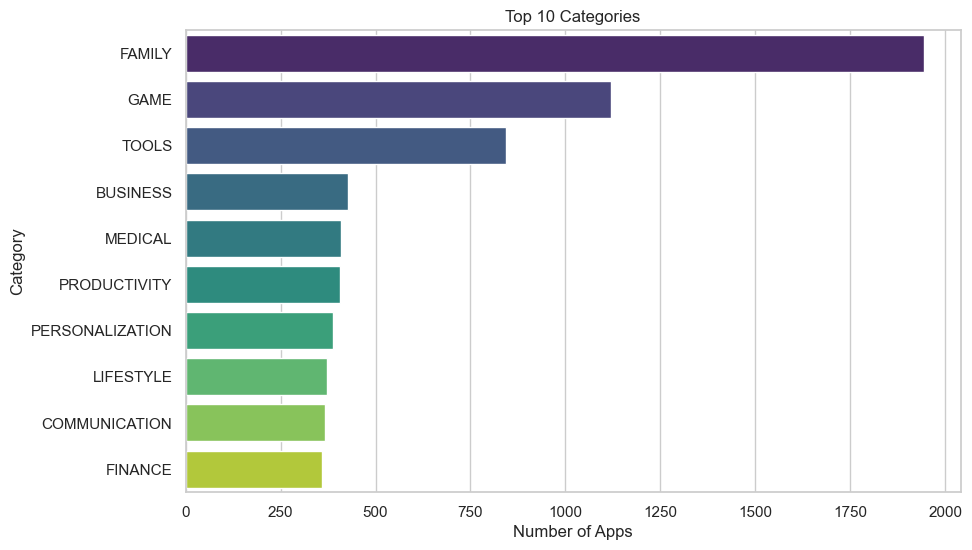

In [43]:
top_category=cleaned_data['Category'].value_counts().head(10)
print("Top 10 Category:\n",top_category)

plt.figure(figsize=(10,6))
sns.barplot(x=top_category.values,y=top_category.index,palette='viridis')
plt.title('Top 10 Categories')
plt.xlabel('Number of Apps')
plt.ylabel('Category')
plt.show()

Category
EDUCATION              4.374564
EVENTS                 4.363647
ART_AND_DESIGN         4.350462
BOOKS_AND_REFERENCE    4.311943
PERSONALIZATION        4.305620
PARENTING              4.282223
GAME                   4.277598
BEAUTY                 4.260882
HEALTH_AND_FITNESS     4.251656
SOCIAL                 4.247001
Name: Rating, dtype: float64


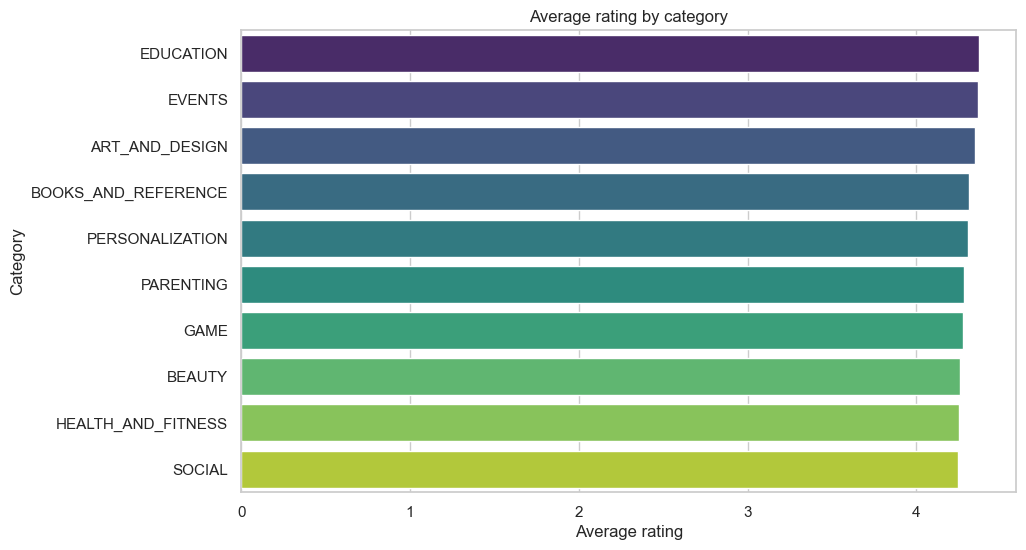

In [48]:
average_rating=cleaned_data.groupby('Category')['Rating'].mean().sort_values(ascending=False).head(10)
print(average_rating)

plt.figure(figsize=(10,6))
sns.barplot(x=average_rating.values,y=average_rating.index,palette='viridis')
plt.title('Average rating by category')
plt.xlabel('Average rating')
plt.ylabel('Category')
plt.show()

Type
Free    9591
Paid     765
Name: count, dtype: int64


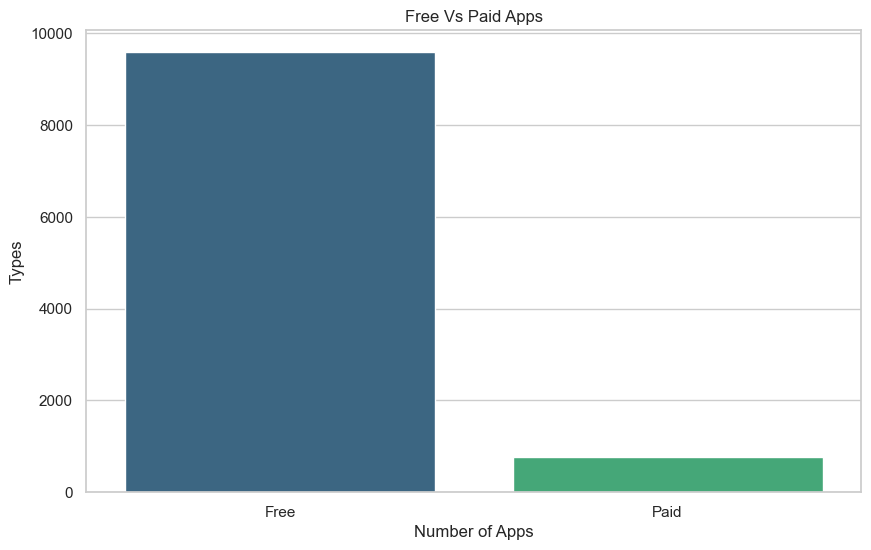

In [55]:
app_types=cleaned_data['Type'].value_counts()
print(app_types)

plt.figure(figsize=(10,6))
sns.barplot(x=app_types.index,y=app_types.values,palette='viridis')
plt.title('Free Vs Paid Apps')
plt.xlabel('Number of Apps')
plt.ylabel('Types')
plt.show()

D:\anaconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


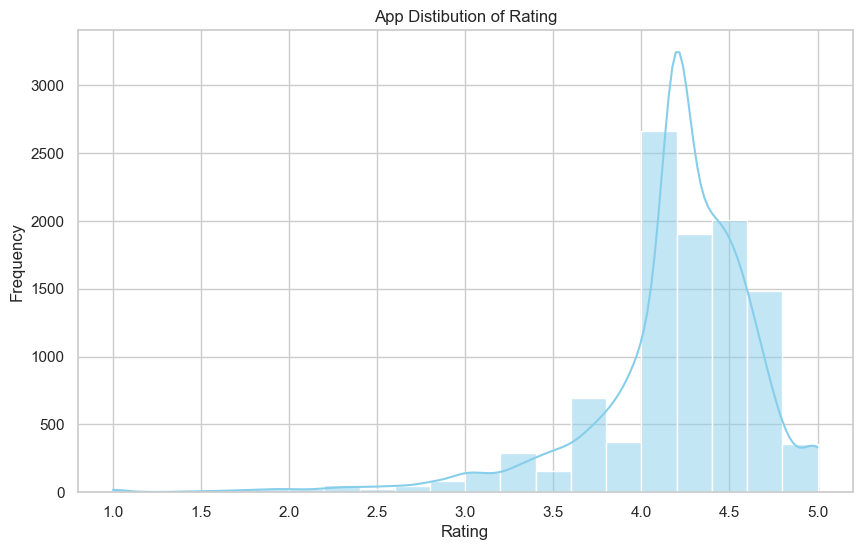

In [56]:
#Histogram
plt.figure(figsize=(10,6))
sns.histplot(cleaned_data['Rating'],bins=20,kde=True,color='skyblue')
plt.title('App Distibution of Rating')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

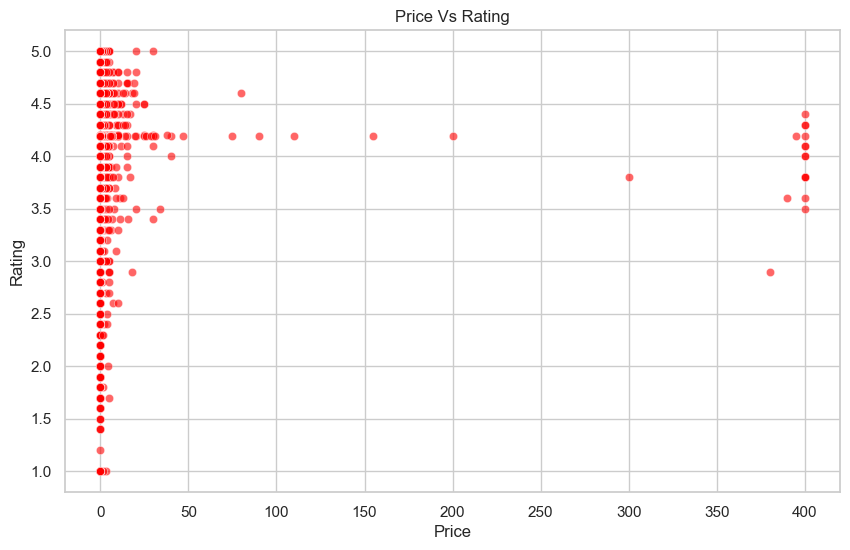

In [59]:
#Scatter Plot
plt.figure(figsize=(10,6))
sns.scatterplot(x='Price',y='Rating',data=cleaned_data,alpha=0.6,color='red')
plt.title('Price Vs Rating')
plt.xlabel('Price')
plt.ylabel('Rating')
plt.show()

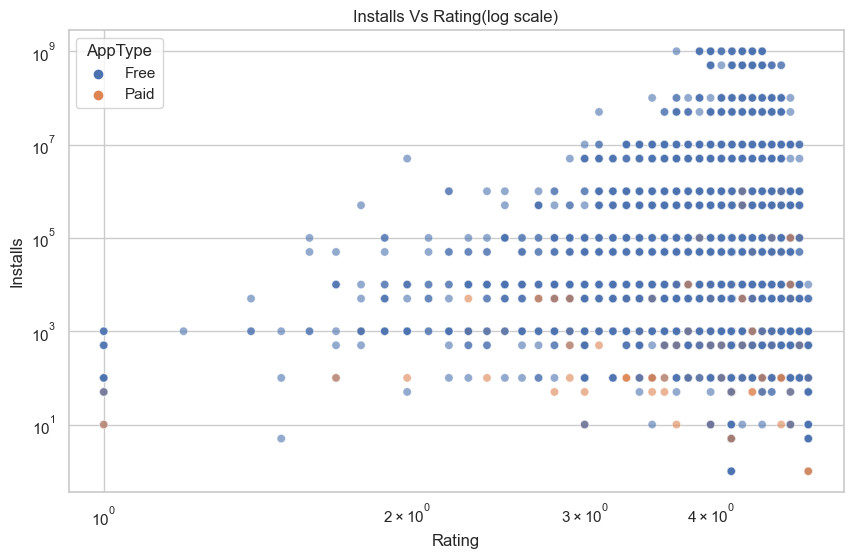

In [61]:
plt.figure(figsize=(10,6))
sns.scatterplot(y='Installs',x='Rating',data=cleaned_data,alpha=0.6,color='red',hue='Type')
plt.xscale('log')
plt.yscale('log')
plt.title('Installs Vs Rating(log scale)')
plt.xlabel('Rating')
plt.ylabel('Installs')
plt.legend(title='AppType')
plt.show()

Correlation matrix:
             Rating   Reviews  Installs     Price    Ispaid
Rating    1.000000  0.068363  0.050473 -0.020559  0.034605
Reviews   0.068363  1.000000  0.634997 -0.009417 -0.041262
Installs  0.050473  0.634997  1.000000 -0.011147 -0.049513
Price    -0.020559 -0.009417 -0.011147  1.000000  0.224234
Ispaid    0.034605 -0.041262 -0.049513  0.224234  1.000000


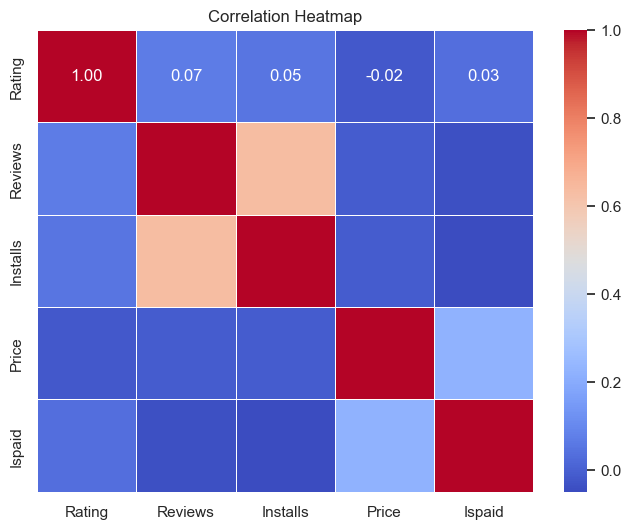

In [67]:
corr=cleaned_data[['Rating','Reviews','Installs','Price','Ispaid']].corr()
print("Correlation matrix:\n",corr)
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap='coolwarm',linewidths=0.5,fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [68]:
cleaned_data.describe().to_csv('EDA_Summary_playstore_dataset.csv')
print('Saved Successful')

Saved Successful
